## Overall: 
PatchCore is a state-of-the-art unsupervised anomaly detection method designed for visual inspection tasks, particularly in industrial settings. It excels at identifying defects in images when only normal (non-defective) samples are available for training.​

<img src="https://anomalib.readthedocs.io/en/v0.3.7/_images/architecture3.jpg">


## How PatchCore Works
- Feature Extraction: A pretrained convolutional neural network (CNN), such as Wide ResNet-50, extracts mid-level features from patches of normal images. These features capture essential patterns without being overly specific to the original training data.

- Memory Bank Creation: The extracted patch features are stored in a memory bank. To manage computational resources efficiently, PatchCore employs coreset subsampling, selecting a representative subset of features that best describe the normal data distribution.

- Anomaly Detection via Nearest Neighbor Search: During inference, features from a test image are compared against the memory bank using nearest neighbor search. If a patch's features significantly deviate from those in the memory bank, it's flagged as anomalous.

- Anomaly Scoring and Localization: An anomaly score is computed for each patch based on its distance to the nearest neighbor in the memory bank. These scores are aggregated to produce an anomaly heatmap, highlighting regions in the image that are likely defective.#

## PatchCore Algorithm

### 1. Feature Extraction
- Given an image $x$, extract a feature map using a pretrained CNN:  
  $$
  f(x) \in \mathbb{R}^{H \times W \times C}
  $$
- Flatten spatial dimensions into a set of patch feature vectors:  
  $$
  \text{patches}(x) = \{ f(x)_{i,j} \mid 1 \leq i \leq H, 1 \leq j \leq W \}
  $$
- Each patch is a vector in $\mathbb{R}^C$.

---

### 2. Coreset Selection (K-Center Greedy)
- From all training patches, select a subset $\mathcal{C}$ that covers the space well.
- Iteratively select patch $p$ that maximizes minimum distance to the current coreset:
  $$
  p = \arg\max_{p' \in \mathcal{P}} \left( \min_{q \in \mathcal{C}} \| p' - q \|_2 \right)
  $$
- Reduces memory while preserving diversity of patches.

---

### 3. Anomaly Scoring
- For a given test patch $p$, compute distance to nearest coreset patch:
  $$
  d(p) = \min_{q \in \mathcal{C}} \| p - q \|_2
  $$
- Aggregate patch distances for the whole image:
  - Maximum patch score,
  - or average of top-$k$ patch scores.

- Final anomaly map highlights localized defects; final image score detects global anomalies.

---


✅ Advantages of PatchCore

Only requires normal images for training: No need for defect images, which is very convenient for industries where collecting defect samples is difficult.

Lightweight and fast: Uses sample selection (coreset) techniques, making testing faster and less resource-intensive.

High accuracy: PatchCore is currently among the best methods for image anomaly detection.

Provides defect maps: Generates heatmaps to show which areas of the image are defective.

⚠️ Disadvantages of PatchCore

Sensitive to positional shifts: If the image is rotated, flipped, or slightly misaligned, PatchCore can easily misdetect.

Depends on pretrained CNN networks: Uses networks trained on ImageNet, which may not always match specific types of data.

Hard to adapt to new domains: If the data is very different from what it’s familiar with, additional fine-tuning is needed.

🛠️ Use Cases
- Industrial Quality Control: Detecting defects in manufacturing processes, such as identifying scratches or dents on products.​
MathWorks - Maker of MATLAB and Simulink

- Medical Imaging: Identifying anomalies in medical scans where abnormal samples are scarce.​
MathWorks - Maker of MATLAB and Simulink

- Infrastructure Monitoring: Monitoring structural components like bridges or buildings for defects or wear.​
MathWorks - Maker of MATLAB and Simulink

- Agricultural Inspection: Detecting diseases or defects in crops and produce.

In [11]:
# Codes are developed with the help of ChatGPT
### Section 1: Imports & Configuration
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.io import read_image
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, precision_recall_curve,
    average_precision_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import optuna
import cv2

# Device & Dataloader settings
DEVICE = torch.device('mps' if torch.backends.mps.is_available() 
                      else 'cuda' if torch.cuda.is_available() 
                      else 'cpu')
NUM_WORKERS = 0 if DEVICE.type == 'mps' else 4
PIN_MEMORY = DEVICE.type != 'cpu'

# Percentile threshold for segmentation masks
SEGMENTATION_PERCENTILE = 90


### Section 2: Dataset Definition
class MVTecDataset(Dataset):
    def __init__(self, root, category, split="train", transform=None, load_mask=False):
        self.transform = transform
        self.load_mask = load_mask
        self.samples = []
        if split == "train":
            img_dir = os.path.join(root, category, "train", "good")
            for fname in sorted(os.listdir(img_dir)):
                self.samples.append((os.path.join(img_dir, fname), 0))
        else:
            img_dir = os.path.join(root, category, "test")
            for sub in sorted(os.listdir(img_dir)):
                label = 0 if sub == "good" else 1
                for fname in sorted(os.listdir(os.path.join(img_dir, sub))):
                    self.samples.append((os.path.join(img_dir, sub, fname), label))
        self.root, self.category, self.split = root, category, split

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = read_image(path).float() / 255.0
        mask = torch.zeros((1, img.shape[1], img.shape[2]))
        if self.load_mask and label == 1:
            mpath = path.replace("/test/", "/ground_truth/")
            mpath = mpath.replace(".png", "_mask.png")
            if os.path.exists(mpath):
                m = read_image(mpath).float() / 255.0
                mask = (m > 0.5).float()
        if self.transform:
            img = self.transform(img)
            mask = self.transform(mask)
        return img, label, mask


### Section 3: Feature Extractor (Layer3 only)
class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        layers = list(backbone.children())
        self.prep = nn.Sequential(*layers[:6])  # conv1..layer2
        self.layer3 = layers[6]                # only layer3

    def forward(self, x):
        x = self.prep(x)
        x = self.layer3(x)
        return x


### Section 4: Coreset Builder via KMeans
def kmean_coreset(vectors: np.ndarray, n_centers: int, random_state: int = 42) -> np.ndarray:
    km = KMeans(n_clusters=n_centers, random_state=random_state)
    km.fit(vectors)
    return km.cluster_centers_


def build_coreset(features: torch.Tensor, sampling_ratio: float) -> torch.Tensor:
    B, C, H, W = features.shape
    flat = features.permute(0,2,3,1).reshape(-1, C).cpu().numpy()
    n_centers = max(1, int(len(flat) * sampling_ratio))
    centers = kmean_coreset(flat, n_centers)
    return torch.from_numpy(centers).to(features.device)


### Section 5: Embedding Extraction
def extract_embeddings(dataloader, model, device):
    model.eval()
    feats, labels, masks, imgs = [], [], [], []
    with torch.no_grad():
        for img_batch, lbl_batch, msk_batch in dataloader:
            imgs.append(img_batch)
            labels.append(lbl_batch)
            masks.append(msk_batch)
            img_batch = img_batch.to(device)
            feats.append(model(img_batch).cpu())
    return torch.cat(feats), torch.cat(labels), torch.cat(masks), torch.cat(imgs)


### Section 6: Hyperparameter Tuning (Optuna, optimize PR-AUC)
from sklearn.metrics import average_precision_score

def tune_params(train_loader, val_loader, device, model, n_trials=10):
    def objective(trial):
        ratio = trial.suggest_float("sampling_ratio", 0.001, 0.1)
        t_feats, _, _, _ = extract_embeddings(train_loader, model, device)
        coreset = build_coreset(t_feats, ratio)
        v_feats, v_labels, _, _ = extract_embeddings(val_loader, model, device)
        B, C, H, W = v_feats.shape
        flat = v_feats.permute(0,2,3,1).reshape(-1, C).to(device)
        d = torch.cdist(flat, coreset.to(device))
        scores = d.min(dim=1)[0].view(B, H, W).mean(dim=[1,2]).cpu().numpy()
        return average_precision_score(v_labels.numpy(), scores)

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)
    best_ratio = study.best_params["sampling_ratio"]

    # find best threshold on val set using F1
    t_feats, _, _, _ = extract_embeddings(train_loader, model, device)
    coreset = build_coreset(t_feats, best_ratio)
    v_feats, v_labels, _, _ = extract_embeddings(val_loader, model, device)
    B, C, H, W = v_feats.shape
    flat = v_feats.permute(0,2,3,1).reshape(-1, C).to(device)
    d = torch.cdist(flat, coreset.to(device))
    scores = d.min(dim=1)[0].view(B, H, W).mean(dim=[1,2]).cpu().numpy()
    best_f1, best_thr = 0.0, 0.0
    for thr in np.linspace(scores.min(), scores.max(), 100):
        preds = (scores > thr).astype(int)
        f1 = f1_score(v_labels.numpy(), preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr

    return best_ratio, best_thr


### Section 7: Compute Anomaly Maps
def compute_anomaly_maps(test_loader, model, ratio, device):
    feats, labels, masks, imgs = extract_embeddings(test_loader, model, device)
    B, C, H_f, W_f = feats.shape
    coreset = build_coreset(feats, ratio)
    flat = feats.permute(0,2,3,1).reshape(-1, C).to(device)
    d = torch.cdist(flat, coreset.to(device))
    amap_feat = d.min(dim=1)[0].view(B, H_f, W_f).cpu().numpy()

    anomaly_maps = np.zeros((B, 224, 224), dtype=float)
    for i in range(B):
        anomaly_maps[i] = cv2.resize(amap_feat[i], (224, 224), interpolation=cv2.INTER_LINEAR)
    image_scores = anomaly_maps.reshape(B, -1).mean(axis=1)
    return anomaly_maps, image_scores, labels.numpy(), masks, imgs


### Section 8: Evaluation Metrics
def evaluate_metrics(image_scores, labels, anomaly_maps, masks, threshold, seg_percentile=SEGMENTATION_PERCENTILE):
    """
    1) Image‐level metrics dựa trên image_scores và threshold
    2) Pixel‐level metrics dựa trên anomaly_maps và masks
    Trả về dict img_metrics, pix_metrics
    """
    # --- Image‐level ---
    preds_img = (image_scores > threshold).astype(int)
    img_metrics = {
        "Accuracy":  accuracy_score(labels, preds_img),
        "Precision": precision_score(labels, preds_img, zero_division=0),
        "Recall":    recall_score(labels, preds_img, zero_division=0),
        "F1":        f1_score(labels, preds_img, zero_division=0),
        "ROC AUC":   roc_auc_score(labels, image_scores),
        "PR AUC":    average_precision_score(labels, image_scores)
    }

    # --- Pixel‐level ---
    pixel_pred = anomaly_maps.reshape(-1)
    pixel_gt   = masks.squeeze(1).numpy().reshape(-1).astype(int)
    pix_thresh = np.percentile(pixel_pred, seg_percentile)
    pixel_pred_bin = (pixel_pred > pix_thresh).astype(int)
    pix_metrics = {
        "Accuracy":  accuracy_score(pixel_gt, pixel_pred_bin),
        "Precision": precision_score(pixel_gt, pixel_pred_bin, zero_division=0),
        "Recall":    recall_score(pixel_gt, pixel_pred_bin, zero_division=0),
        "F1":        f1_score(pixel_gt, pixel_pred_bin, zero_division=0),
        "ROC AUC":   auc(*roc_curve(pixel_gt, pixel_pred)[:2]),
        "PR AUC":    average_precision_score(pixel_gt, pixel_pred)
    }

    return img_metrics, pix_metrics



===== Processing 'hazelnut' =====


[I 2025-05-07 18:43:50,610] A new study created in memory with name: no-name-1b9b93e3-748a-4d4a-9af1-0ceb41f3bd97
[I 2025-05-07 18:44:58,867] Trial 0 finished with value: 0.936830804778287 and parameters: {'sampling_ratio': 0.010711514976460421}. Best is trial 0 with value: 0.936830804778287.
[I 2025-05-07 18:48:01,834] Trial 1 finished with value: 0.951810175307713 and parameters: {'sampling_ratio': 0.029197094143667904}. Best is trial 1 with value: 0.951810175307713.
[I 2025-05-07 18:49:40,541] Trial 2 finished with value: 0.9421843202072907 and parameters: {'sampling_ratio': 0.013078282710865778}. Best is trial 1 with value: 0.951810175307713.
[I 2025-05-07 18:52:06,840] Trial 3 finished with value: 0.9441291789916363 and parameters: {'sampling_ratio': 0.023646832462283905}. Best is trial 1 with value: 0.951810175307713.
[I 2025-05-07 20:19:41,227] Trial 4 finished with value: 0.9529870527619216 and parameters: {'sampling_ratio': 0.04895951885954507}. Best is trial 4 with value: 0.9

Best image-level threshold = 0.77945
Image-level metrics: {'Accuracy': 0.5636363636363636, 'Precision': 0.7727272727272727, 'Recall': 0.4722222222222222, 'F1': 0.5862068965517241, 'ROC AUC': 0.5935672514619883, 'PR AUC': 0.7788467587396598}
Pixel-level metrics: {'Accuracy': 0.8926310296846011, 'Precision': 0.03369231215213358, 'Recall': 0.23882667214630637, 'F1': 0.05905366783105748, 'ROC AUC': 0.6953201724339025, 'PR AUC': 0.03087075255428253}


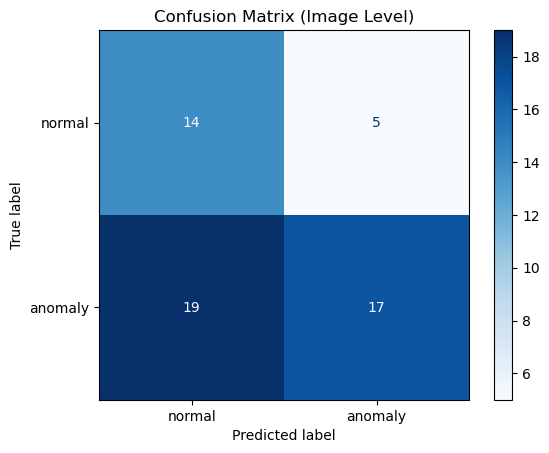

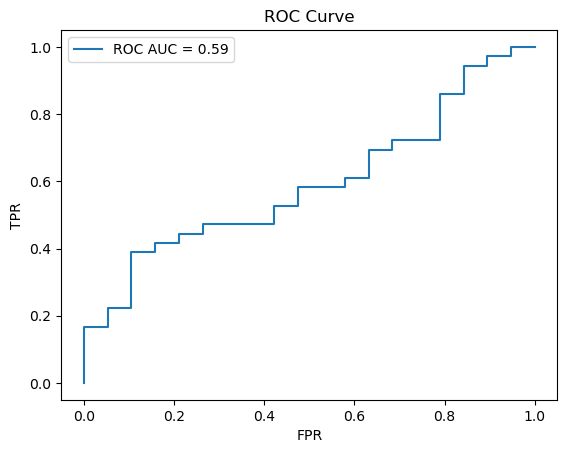

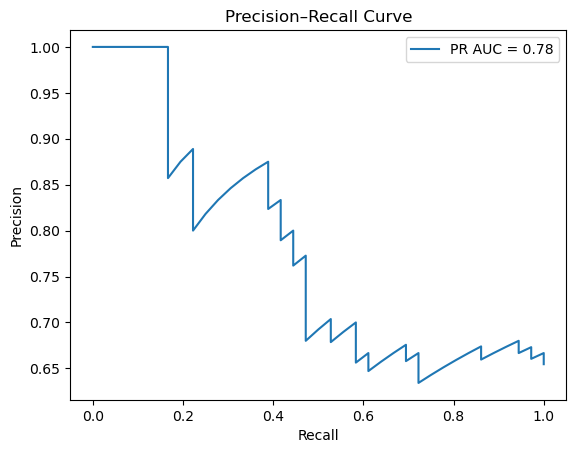

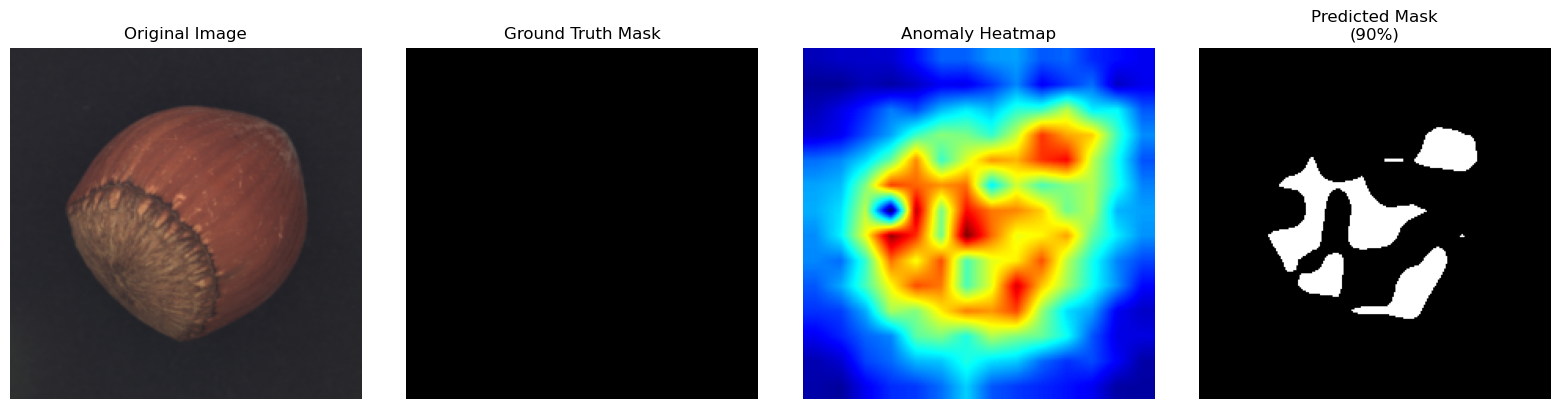

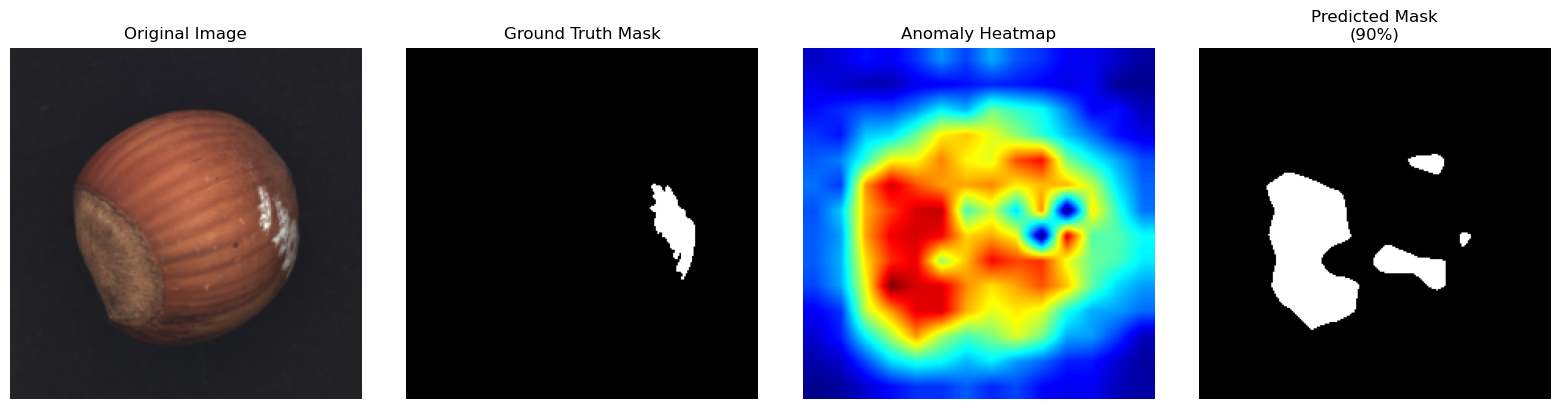

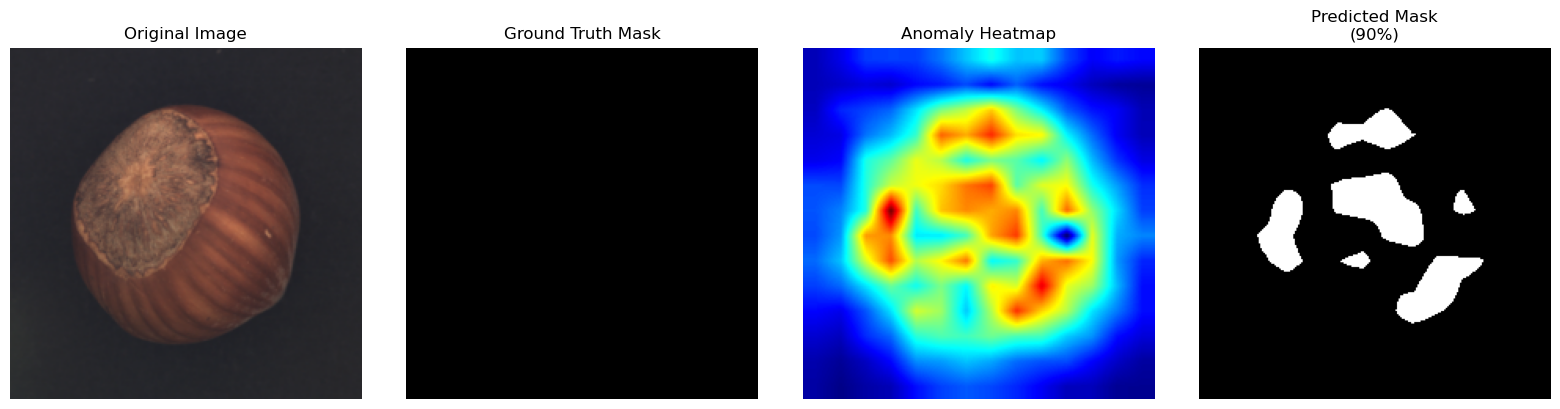


===== Processing 'carpet' =====


[I 2025-05-07 21:10:41,347] A new study created in memory with name: no-name-f5005701-fc59-4c31-8bdc-c1f8c359c232
[I 2025-05-07 21:12:09,461] Trial 0 finished with value: 0.9375972162076053 and parameters: {'sampling_ratio': 0.016311803188330407}. Best is trial 0 with value: 0.9375972162076053.
[I 2025-05-07 21:14:01,591] Trial 1 finished with value: 0.9370490850750705 and parameters: {'sampling_ratio': 0.0209402369031401}. Best is trial 0 with value: 0.9375972162076053.
[I 2025-05-07 21:18:52,630] Trial 2 finished with value: 0.9387785480783437 and parameters: {'sampling_ratio': 0.06040800547756209}. Best is trial 2 with value: 0.9387785480783437.
[I 2025-05-07 21:20:50,540] Trial 3 finished with value: 0.9366672625205561 and parameters: {'sampling_ratio': 0.022884271700279103}. Best is trial 2 with value: 0.9387785480783437.
[I 2025-05-07 21:22:15,622] Trial 4 finished with value: 0.9371260048347988 and parameters: {'sampling_ratio': 0.013090288541098467}. Best is trial 2 with value:

Best image-level threshold = 0.61080
Image-level metrics: {'Accuracy': 0.23728813559322035, 'Precision': 0.8, 'Recall': 0.08333333333333333, 'F1': 0.1509433962264151, 'ROC AUC': 0.5965909090909092, 'PR AUC': 0.8621654823835944}
Pixel-level metrics: {'Accuracy': 0.8929905714934279, 'Precision': 0.01756863116008364, 'Recall': 0.16695557267591166, 'F1': 0.03179182801482926, 'ROC AUC': 0.3501610605910741, 'PR AUC': 0.012307413121186765}


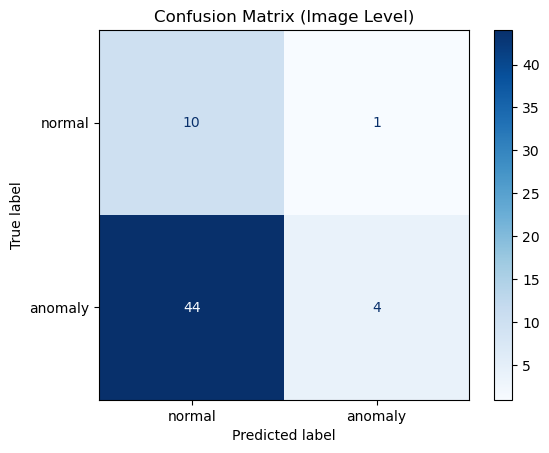

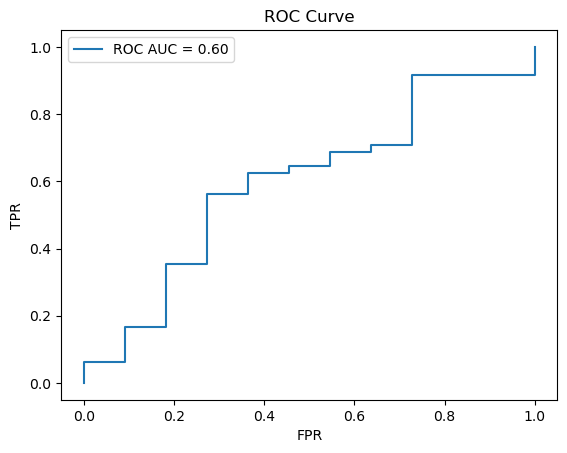

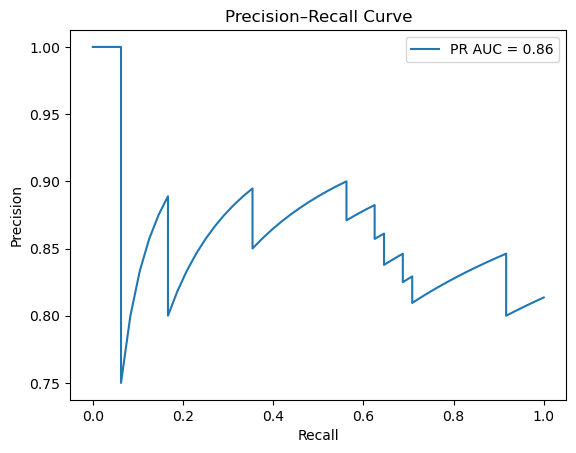

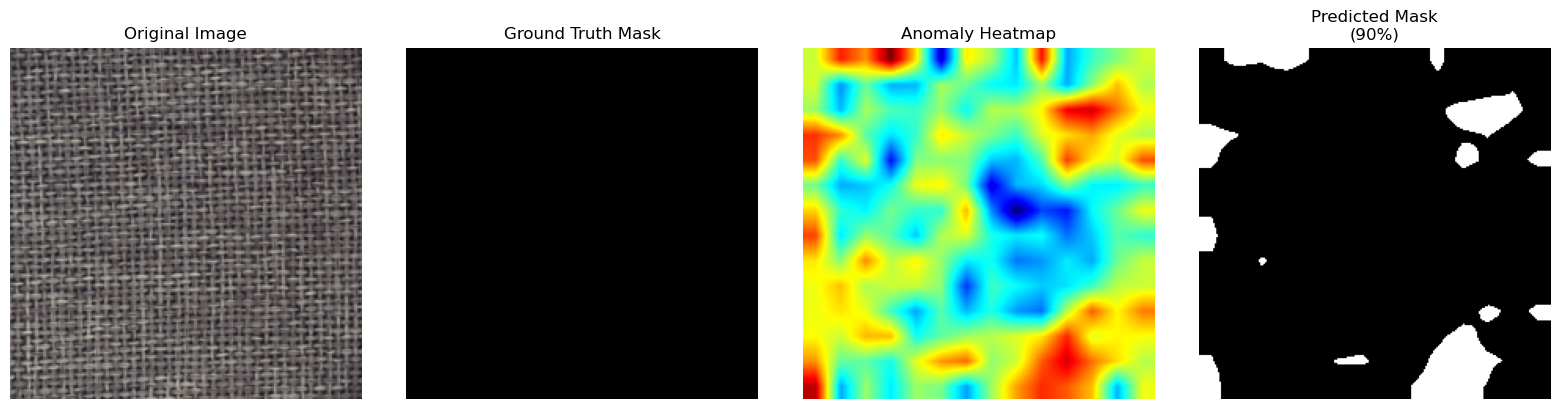

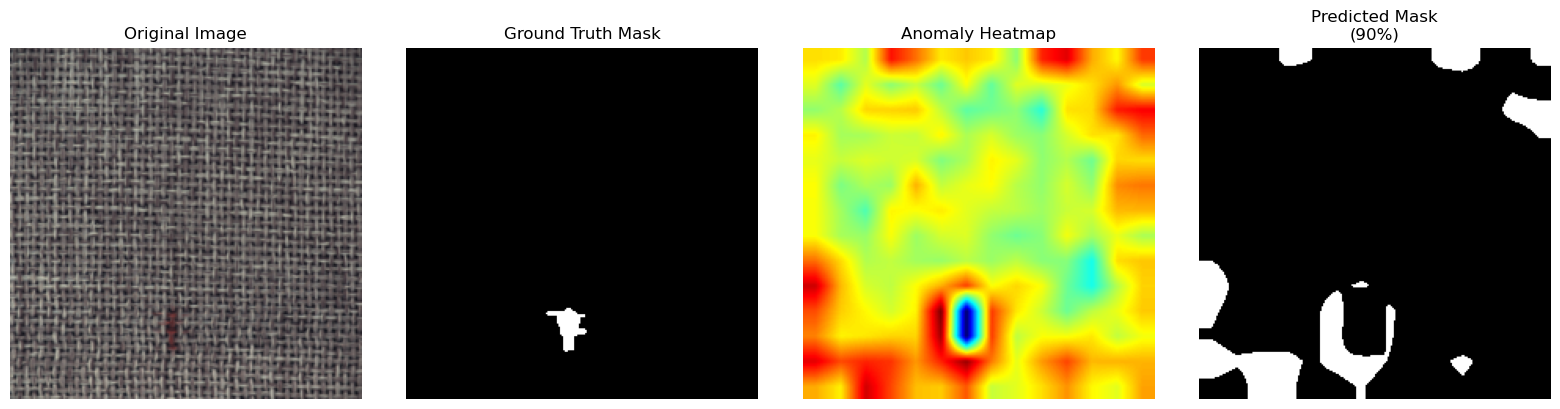

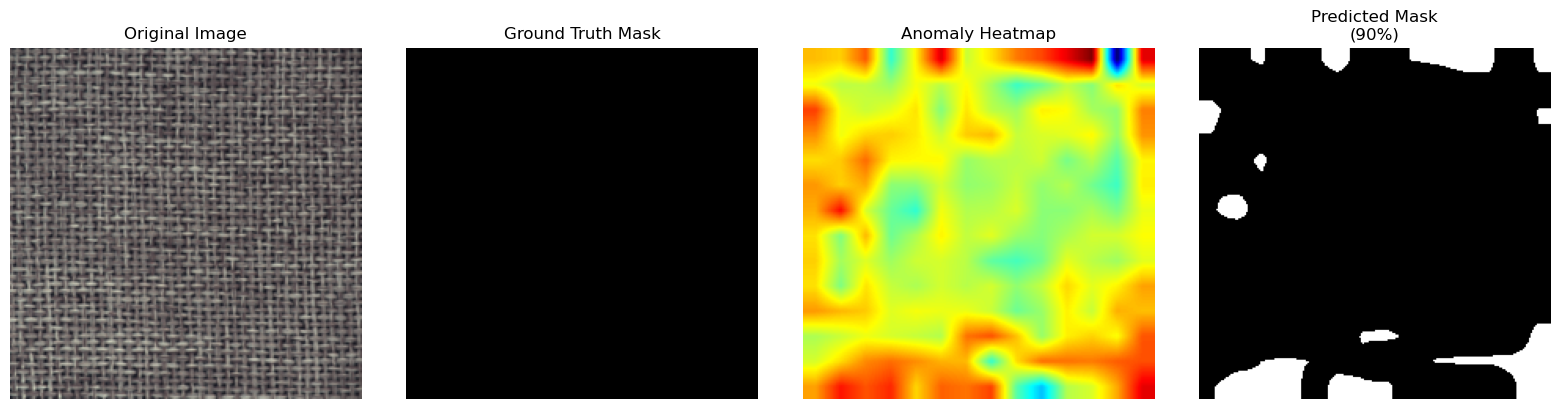

In [ ]:
# ### 9. Plotting Results

def plot_results(labels, image_scores, threshold):
    # Confusion Matrix (Image Level)
    preds = (image_scores > threshold).astype(int)
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["normal", "anomaly"])
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix (Image Level)")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(labels, image_scores)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.2f}")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    # Precision–Recall Curve
    prec, rec, _ = precision_recall_curve(labels, image_scores)
    pr_auc = average_precision_score(labels, image_scores)
    plt.figure()
    plt.plot(rec, prec, label=f"PR AUC = {pr_auc:.2f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curve")
    plt.legend()
    plt.show()


# ### 10. High-Quality Visualization

def visualize_results(img_tensor, gt_mask, anomaly_map, threshold_pct=SEGMENTATION_PERCENTILE, dpi=100):
    # convert to H×W×C uint8
    img = (img_tensor.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
    # ground truth mask
    gt = (gt_mask.squeeze(0).cpu().numpy() > 0.5).astype(np.uint8) * 255

    # normalize and resize anomaly_map to image size
    norm = (anomaly_map - anomaly_map.min()) / (anomaly_map.max() - anomaly_map.min() + 1e-6)
    amap_uint8 = (norm * 255).astype(np.uint8)
    amap_res = cv2.resize(amap_uint8, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_LINEAR)

    # heatmap & predicted mask
    heatmap = cv2.applyColorMap(amap_res, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    pred_mask = (amap_res > np.percentile(amap_res, threshold_pct)).astype(np.uint8) * 255

    # plot side-by-side
    fig, axs = plt.subplots(1, 4, figsize=(16, 4), dpi=dpi)
    for ax in axs:
        ax.axis("off")
    axs[0].imshow(img);        axs[0].set_title("Original Image")
    axs[1].imshow(gt, cmap="gray");    axs[1].set_title("Ground Truth Mask")
    axs[2].imshow(heatmap);    axs[2].set_title("Anomaly Heatmap")
    axs[3].imshow(pred_mask, cmap="gray"); axs[3].set_title(f"Predicted Mask\n({threshold_pct}%)")
    plt.tight_layout()
    plt.show()


# ### 11. Run per Category (Main Loop)

def run_category(root, category):
    print(f"\n===== Processing '{category}' =====")
    # Prepare data
    transform = T.Resize((224, 224))
    full = MVTecDataset(root, category, split="test", transform=transform, load_mask=True)
    vsz = len(full) // 2
    val_ds, test_ds = random_split(full, [vsz, len(full) - vsz])
    train_ds = MVTecDataset(root, category, split="train", transform=transform, load_mask=False)

    loaders = {
        'train': DataLoader(train_ds, batch_size=32, shuffle=True,
                            num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY),
        'val':   DataLoader(val_ds,   batch_size=32,
                            num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY),
        'test':  DataLoader(test_ds,  batch_size=32,
                            num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    }

    # Model
    model = FeatureExtractor().to(DEVICE)

    # 1) Hyperparameter tuning
    best_ratio, best_thr = tune_params(loaders['train'], loaders['val'], DEVICE, model)
    print(f"Best image-level threshold = {best_thr:.5f}")


    # 2) Compute anomaly maps & scores
    amaps, scores, labels, masks, imgs = compute_anomaly_maps(
        loaders['test'], model, best_ratio, DEVICE
    )

    # 3) Evaluate metrics
    img_m, pix_m = evaluate_metrics(
        scores, labels, amaps, masks, best_thr, SEGMENTATION_PERCENTILE
    )

    print("Image-level metrics:", img_m)
    print("Pixel-level metrics:", pix_m)

    # 4) Plot overall results
    plot_results(labels, scores, best_thr)

    # 5) Show individual examples
    import random
    for idx in random.sample(range(len(imgs)), k=3):
        visualize_results(
            imgs[idx], masks[idx], amaps[idx], SEGMENTATION_PERCENTILE
        )

# ### 12. Execution

if __name__ == "__main__":
    DATA_ROOT = "/Users/toni/Downloads/datasets/MVTecAD"
    for cat in ["hazelnut", "carpet"]:
        run_category(DATA_ROOT, cat)
